# Лабораторная работа №3

ФИО:   
Группа:

Отправлять можно следующими способами:
1. Запушить этот ноутбук в GitHub в репозиторий, где у вас лежат ноутбуки с лабами

Deadlines:
- Занятие №7 в семестре (Занятие №3 очное)

Что необходимо сделать:  
- Обучить различного рода модели машинного обучения и сравнить их между собой  

---
## Читайте задание внимательно

Исходные данные:
1. В [табличке](https://docs.google.com/spreadsheets/d/1k2MYXEp_OVQrink_XRC1PwoM0ZuNMeNz4VTWY7cI3hE/edit?usp=sharing) необходимо узнать название своего датасета
2. Скачать нужны вам данные можно в [Google Drive](https://drive.google.com/drive/folders/1Phm-Fq1GL-VX7NS-DCEMRh_Fo1wU7DQ9?usp=sharing)
  
---
Теперь по пунктам, что я от вас жду:  
1. Загрузить необходимые данные к себе и считать (read) их в переменную.
2. Понять, у вас задача классификации (бинарной или многоклассовой) или регрессии (**если у вас многоклассовая классификация, прочтите P.S.S. внизу**).
3. Сделать предобработку данных:  
     1. Разделить выборку на тренировочную (train) и тестовую (test). _Обратите внимание, что обучать скейлеры и определять, какими значениями вы будете заполнять пропуски, вы будете на train выборке, а применять и на train, и на test_.
     2. Проверить пропуски в данных. Если они есть, заполнить одной из стратегий, предложенных в ноутбуке для семинара №3. P.S. Для численных и категориальных переменных будут разные стратегии.
     3. Отнормировать численные переменные (`StandardScaler`, `MinMaxScaler`).
     4. Закодировать категориальные признаки по одной из стратегий.
4. Обучить на тренировочном множестве:
     1. Линейную модель (`LogisticRegression`, `LinearRegression`)
     2. Деревянную модель (`DecisionTreeClassifier`, `DecisionTreeRegressor`) (тут советую попробовать разные глубины деревьев)
     3. K-ближайших соседей (`KNeighborsClassifier`, `KNeighborsRegressor`) (тут тоже есть смысл попробовать разные `k`)
     4. Случайный лес (`RandomForestClassifier`, `RandomForestRegressor`)
5. Посчитайте метрики на train и test множествах:
     1. Для задачи классификации -- Accuracy, ROC-AUC (график + значение), PR-кривую (график), F1-score
     2. Для задачи регрессии -- MAE, RMSE, MAPE
6. Сравните метрики относительно train/test, так и относительно разных моделей. Ответьте на следующие вопросы:
     1. Какая модель справилась лучше с поставленной задачей?
     2. Имеет ли место переобучение?
     3. Имеет ли место недообучение?
     4. Как можно улучшить метрики моделей?

---
P.S.  
Просьба -- делать каждое задание в отдельных ячейках и с отдельными заголовками (как пункт 1 и 2 в этом ноутбуке) типа  
- Заголовок
- Ячейки с кодом
- Другой заголовок
- Другие ячейки с кодом

P.S.S.  
Если вам повезло с многоклассовой классификацией, вам будет необходимо понять, умеет ли алгоритм работать с несколькими классами одновременно (обычно они не умеют). Поэтому вам может понадобиться такая штука, как OneVsRestClassifier ([ссылка](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html#sklearn.multiclass.OneVsRestClassifier)), но советую ознакомиться с этой [страницей](https://scikit-learn.org/stable/modules/multiclass.html), здесь представлена более полная информация.

## 1. Пример импорта данных. Грузим данные

In [434]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")

ds = pd.read_csv(path  + '/Sleep_health_and_lifestyle_dataset.csv')
ds

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## 2. Понимаем, какая перед нами задача

In [435]:
set(ds['Sleep Disorder'])

{'Insomnia', 'Sleep Apnea', nan}

3 результата => многоклассовая ( можно свести к бинарной, если обобщить болезни в болен / не болен )
Т.к датасет маленький, я обобщаю болезни в болен / не болен

## 3. Делаем предобработку данных

In [436]:
ds = ds.drop('Person ID', axis=1) # Дропнем id, т.к оно не имеет смысла в задаче


In [437]:

# le_gender = LabelEncoder()
# le_gender.fit(ds.Gender)
# ds.Gender = le_gender.transform(ds.Gender) # заменим строковые значения на численные

In [438]:
ds

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...
369,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [439]:
# le_occ = LabelEncoder()
# le_occ.fit(ds.Occupation)
# ds.Occupation = le_occ.transform(ds.Occupation) # заменим строковые значения на численные
# ds

In [440]:
# le_occ = LabelEncoder()
# le_occ.fit(ds['BMI Category'])
# ds['BMI Category'] = le_occ.transform(ds['BMI Category']) # заменим строковые значения на численные
# ds

In [441]:
# le_occ.fit(ds['Sleep Disorder'])
# ds['Sleep Disorder'] = le_occ.transform(ds['Sleep Disorder']) # заменим строковые значения на численные
# ds

In [442]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

ds['upper'], ds['lower'] = ds['Blood Pressure'].str.split('/', expand=True)[0], ds['Blood Pressure'].str.split('/', expand=True)[1]
ds = ds.drop('Blood Pressure', axis=1)

numeric_features = ['Age', 'Sleep Duration',
                    'Heart Rate', 'Daily Steps', 'upper', 'lower']

categorical_features = [
    'Occupation','Quality of Sleep','Gender',
    'Physical Activity Level', 'Stress Level', 'BMI Category',
    'Sleep Disorder'
]

ds[numeric_features] = MinMaxScaler().fit_transform(ds[numeric_features])
for cat in categorical_features:
  le = LabelEncoder()
  le.fit(ds[cat])
  ds[cat] = le.transform(ds[cat])
ds


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,upper,lower
0,1,0.00000,9,0.111111,2,4,3,3,0.571429,0.171429,2,0.407407,0.40
1,1,0.03125,1,0.148148,2,9,5,0,0.476190,1.000000,2,0.370370,0.25
2,1,0.03125,1,0.148148,2,9,5,0,0.476190,1.000000,2,0.370370,0.25
3,1,0.03125,6,0.037037,0,0,5,2,0.952381,0.000000,1,0.925926,0.75
4,1,0.03125,6,0.037037,0,0,5,2,0.952381,0.000000,1,0.925926,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,0,1.00000,5,0.851852,5,12,0,3,0.142857,0.571429,1,0.925926,1.00
370,0,1.00000,5,0.814815,5,12,0,3,0.142857,0.571429,1,0.925926,1.00
371,0,1.00000,5,0.851852,5,12,0,3,0.142857,0.571429,1,0.925926,1.00
372,0,1.00000,5,0.851852,5,12,0,3,0.142857,0.571429,1,0.925926,1.00


In [443]:
# # нормализуем значения
# sc = MinMaxScaler()
# cols = ds.columns
# ds = pd.DataFrame(sc.fit_transform(ds), columns=cols)


In [444]:
ds

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,upper,lower
0,1,0.00000,9,0.111111,2,4,3,3,0.571429,0.171429,2,0.407407,0.40
1,1,0.03125,1,0.148148,2,9,5,0,0.476190,1.000000,2,0.370370,0.25
2,1,0.03125,1,0.148148,2,9,5,0,0.476190,1.000000,2,0.370370,0.25
3,1,0.03125,6,0.037037,0,0,5,2,0.952381,0.000000,1,0.925926,0.75
4,1,0.03125,6,0.037037,0,0,5,2,0.952381,0.000000,1,0.925926,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,0,1.00000,5,0.851852,5,12,0,3,0.142857,0.571429,1,0.925926,1.00
370,0,1.00000,5,0.814815,5,12,0,3,0.142857,0.571429,1,0.925926,1.00
371,0,1.00000,5,0.851852,5,12,0,3,0.142857,0.571429,1,0.925926,1.00
372,0,1.00000,5,0.851852,5,12,0,3,0.142857,0.571429,1,0.925926,1.00


In [445]:
from sklearn.model_selection import train_test_split

x = ds.drop('Sleep Disorder', axis=1)
y = ds['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42)


# 4. ОБУЧЕНИЕ

In [446]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

ovr_lr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
rf = RandomForestClassifier()
dt = DecisionTreeClassifier()
knn = KNeighborsClassifier()

for model in (
    ovr_lr,
    rf,
    dt,
    knn
):
  model.fit(X_train, y_train)

Train Metrics for <class 'sklearn.multiclass.OneVsRestClassifier'>:
Accuracy: 0.89, F1-Score: 0.89, ROC-AUC: 0.93
Test Metrics: <class 'sklearn.multiclass.OneVsRestClassifier'>
Accuracy: 0.88, F1-Score: 0.88, ROC-AUC: 0.93


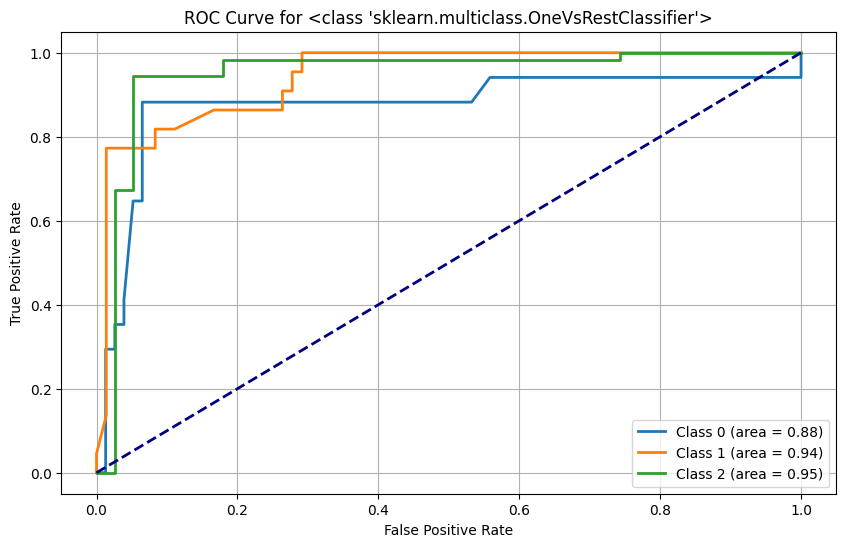

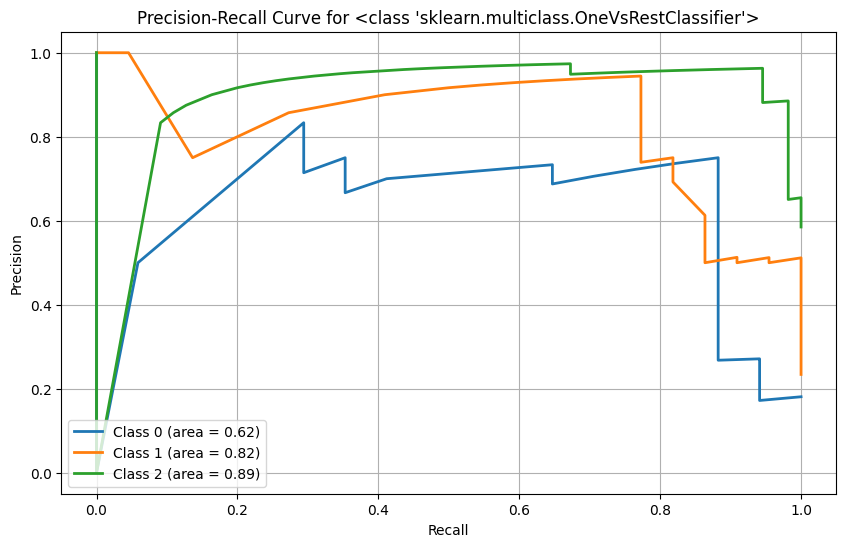

Train Metrics for <class 'sklearn.ensemble._forest.RandomForestClassifier'>:
Accuracy: 0.93, F1-Score: 0.93, ROC-AUC: 0.99
Test Metrics: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Accuracy: 0.89, F1-Score: 0.89, ROC-AUC: 0.95


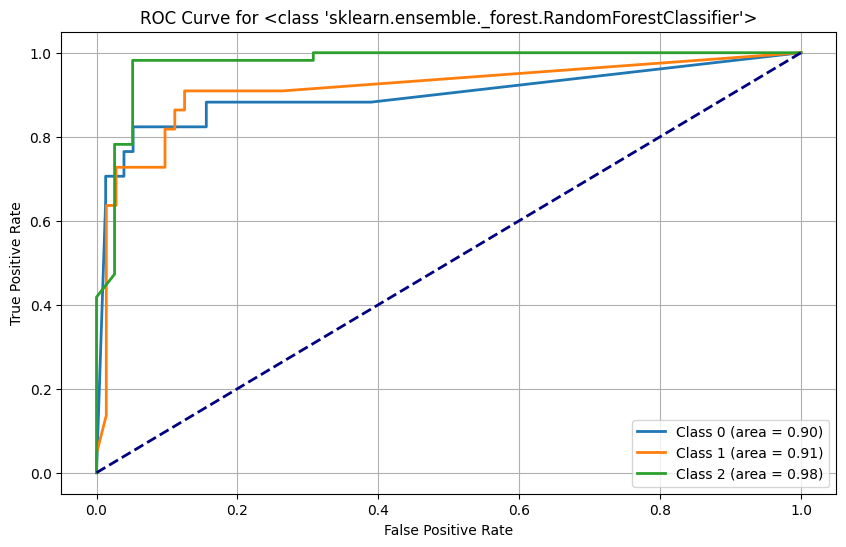

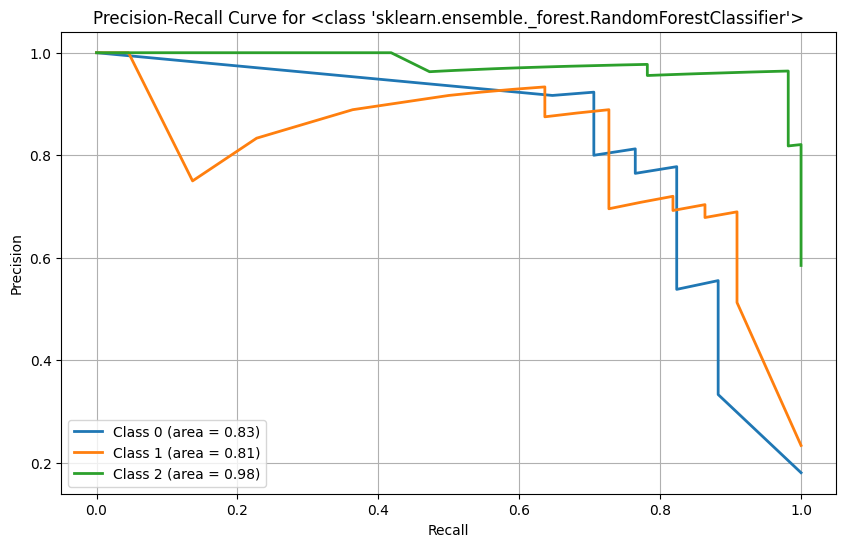

Train Metrics for <class 'sklearn.tree._classes.DecisionTreeClassifier'>:
Accuracy: 0.93, F1-Score: 0.93, ROC-AUC: 0.99
Test Metrics: <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Accuracy: 0.91, F1-Score: 0.91, ROC-AUC: 0.93


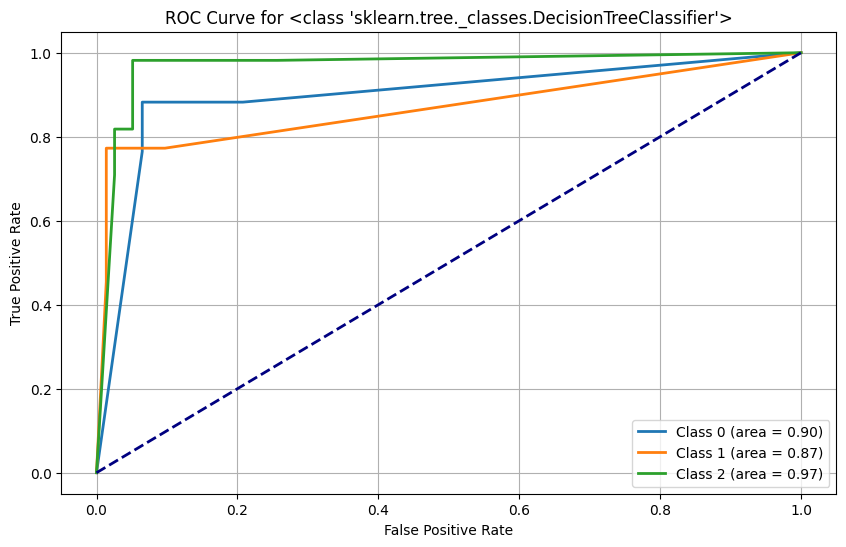

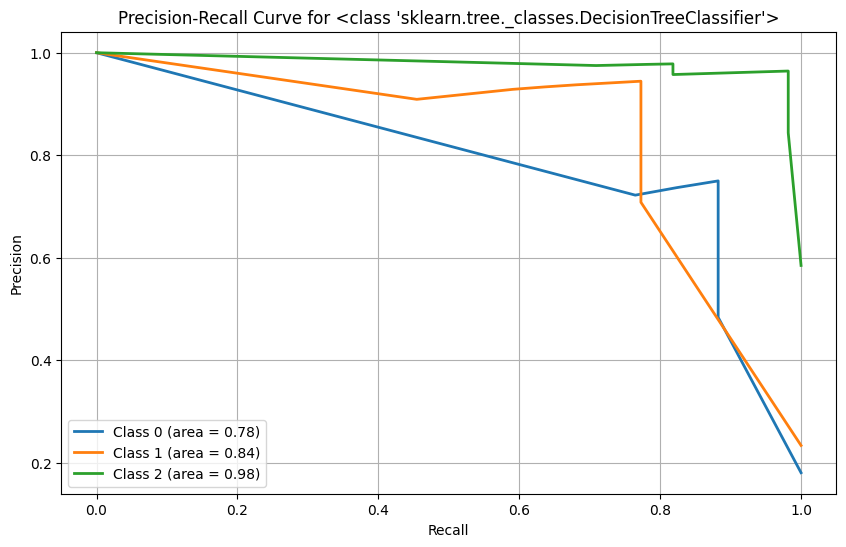

Train Metrics for <class 'sklearn.neighbors._classification.KNeighborsClassifier'>:
Accuracy: 0.90, F1-Score: 0.90, ROC-AUC: 0.97
Test Metrics: <class 'sklearn.neighbors._classification.KNeighborsClassifier'>
Accuracy: 0.87, F1-Score: 0.87, ROC-AUC: 0.93


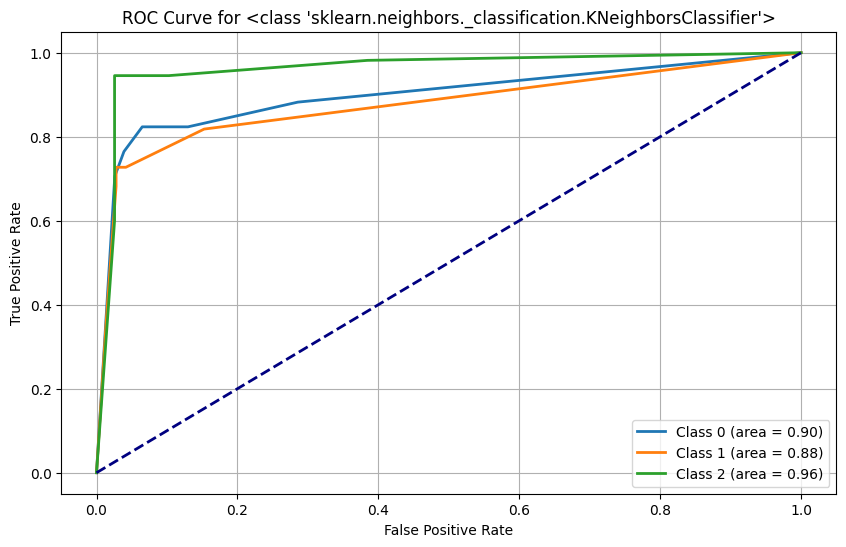

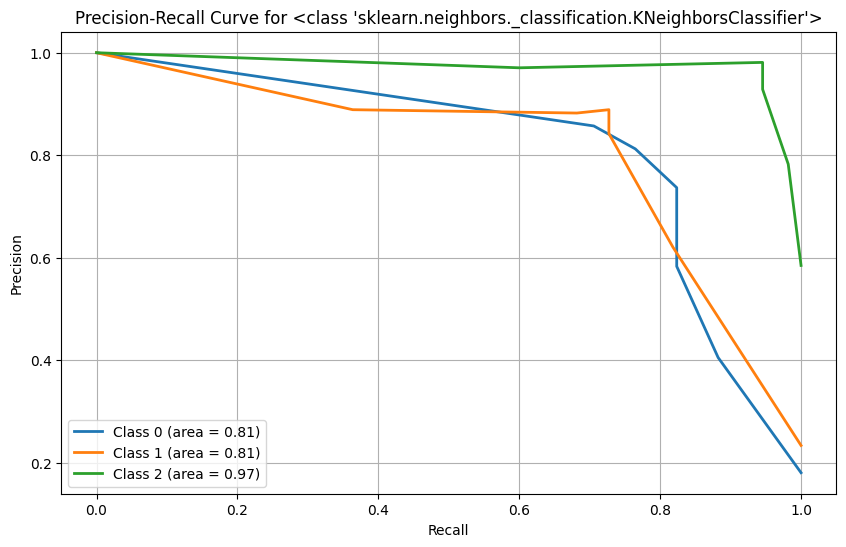

In [447]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

classes = sorted(y_train.unique())
y_train_bin = label_binarize(y_train, classes=classes)
y_test_bin = label_binarize(y_test, classes=classes)

for model in (
    ovr_lr,
    rf,
    dt,
    knn
):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  # Предсказания вероятностей
  y_train_proba = model.predict_proba(X_train)
  y_test_proba = model.predict_proba(X_test)

  # Метрики
  train_accuracy = accuracy_score(y_train, y_train_pred)
  test_accuracy = accuracy_score(y_test, y_test_pred)

  train_f1 = f1_score(y_train, y_train_pred, average='weighted')
  test_f1 = f1_score(y_test, y_test_pred, average='weighted')

  # ROC-AUC для мультиклассовой задачи (OvR)
  train_roc_auc = roc_auc_score(y_train_bin, y_train_proba, average='weighted', multi_class='ovr')
  test_roc_auc = roc_auc_score(y_test_bin, y_test_proba, average='weighted', multi_class='ovr')

  print(f"Train Metrics for {type(model)}:")
  print(f"Accuracy: {train_accuracy:.2f}, F1-Score: {train_f1:.2f}, ROC-AUC: {train_roc_auc:.2f}")

  print(f"Test Metrics: {type(model)}")
  print(f"Accuracy: {test_accuracy:.2f}, F1-Score: {test_f1:.2f}, ROC-AUC: {test_roc_auc:.2f}")

  # ROC-кривая для каждого класса
  plt.figure(figsize=(10, 6))
  for i, class_name in enumerate(classes):
      fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
      roc_auc = auc(fpr, tpr)
      plt.plot(fpr, tpr, lw=2, label=f'Class {class_name} (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'ROC Curve for {type(model)}')
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()

  # PR-кривая для каждого класса
  plt.figure(figsize=(10, 6))
  for i, class_name in enumerate(classes):
      precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_test_proba[:, i])
      pr_auc = auc(recall, precision)
      plt.plot(recall, precision, lw=2, label=f'Class {class_name} (area = {pr_auc:.2f})')
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'Precision-Recall Curve for {type(model)}')
  plt.legend(loc="lower left")
  plt.grid()
  plt.show()